# 05 · Outcomes, duration and composition

Research question: do changes in aggregate finish rates survive division adjustment? Finishes mean KO/TKO, including doctor stoppages, or submission. Result status overrides method for draws and no contests.

In [1]:
from pathlib import Path
import sys
import io
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_loader import load_raw, profile_sources, verify_raw, TABLES
from src.pipeline import prepare
from src.analysis import *
from src.visualization import *
def show(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format='png', bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

## Prepare cohort

Every outcome remains in the denominator of method shares.

In [2]:
data = prepare(save=False)
fights, appearances = cohort(data)
print(f"Cohort: {len(fights):,} fights, {fights.event_id.nunique():,} events, {appearances.fighter_id.nunique():,} fighters")
print(f"Date range: {fights.event_date.min():%Y-%m-%d} to {fights.event_date.max():%Y-%m-%d}")

Cohort: 8,820 fights, 783 events, 2,735 fighters
Date range: 1994-03-11 to 2026-08-08


## Victory methods

KO versus TKO is not separately recoverable from the combined source category. Do not invent that split.

,result_status,method,outcome_group,fights,share_all_fights
0,draw,Decision - Majority,Draw,38,0.004308
1,draw,Decision - Split,Draw,17,0.001927
2,draw,Decision - Unanimous,Draw,7,0.000794
3,draw,Other,Draw,2,0.000227
4,draw,Overturned,Draw,1,0.000113
5,no_contest,Could Not Continue,No contest,33,0.003741
6,no_contest,Overturned,No contest,58,0.006576
7,win,DQ,Other,23,0.002608
8,win,Decision - Majority,Decision,66,0.007483
9,win,Decision - Split,Decision,811,0.091950


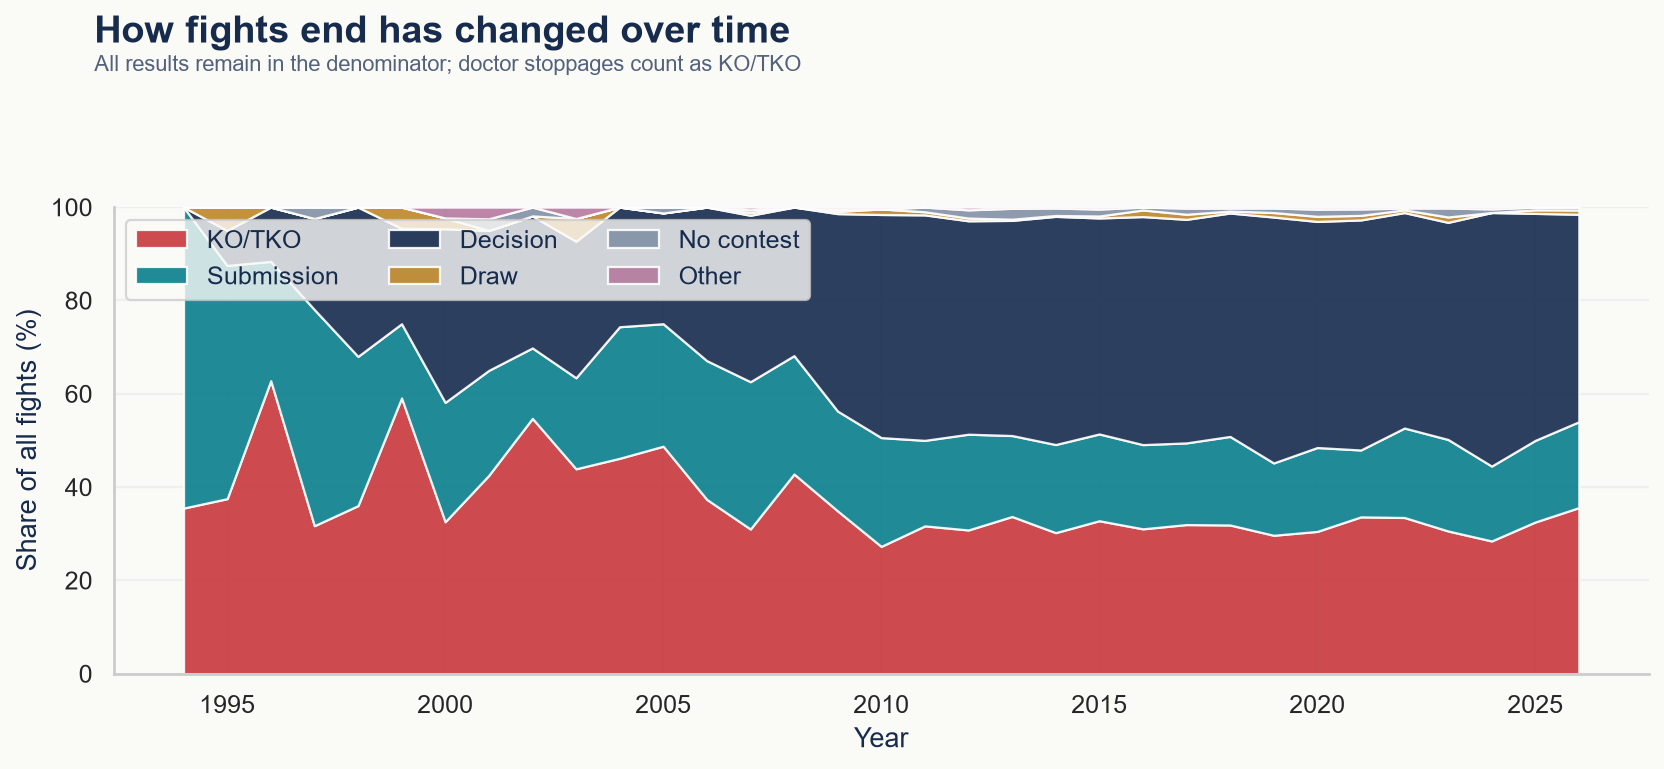

Finish share: 0.5218820861678004


In [3]:
tables = export_outcomes(data)
display(tables['outcome_methods'])
show(outcome_chart(fights))
print('Finish share:', fights.is_finish.mean())

## A composition reversal

Compare full 2010–2019 and 2020–2025 periods. Standardization uses fixed pooled weights over shared divisions with at least 50 fights in each period.

In [4]:
adjustment = composition_adjustment(fights)
display(adjustment)
print('Observed change (percentage points):', adjustment.all_division_decision_rate.diff().iloc[-1]*100)
print('Standardized change (percentage points):', adjustment.standardized_decision_rate.diff().iloc[-1]*100)

,period,all_division_decision_rate,standardized_decision_rate,shared_divisions,retained_fights,all_fights
0,2010–2019,0.482364,0.489434,11,4167,4196
1,2020–2025,0.489285,0.478160,11,2962,3033


Observed change (percentage points): 0.692038042291071
Standardized change (percentage points): -1.1274637216847294


## Duration and scheduled exposure

Title fights often have longer schedules. Show schedule-stratified duration before comparing title status.

In [5]:
display(tables['title_duration'])
display(fights.groupby(['weight_class','outcome_group']).fight_duration_seconds.agg(['count','mean','median']).head(30))
display(tables['ending_rounds'])

,title_fight,scheduled_rounds,fights,minutes
0,0,1.0,52,3.809936
1,0,2.0,99,6.917845
2,0,3.0,7743,10.247477
3,0,4.0,9,11.070370
4,0,5.0,405,14.436831
5,1,1.0,1,3.016667
6,1,2.0,11,14.268182
7,1,3.0,55,9.975758
8,1,4.0,34,10.320098
9,1,5.0,380,15.953816


count         mean  median
weight_class      outcome_group                            
Bantamweight      Decision         412   936.407767   900.0
                  Draw               7   900.000000   900.0
                  KO/TKO           203   374.103448   292.0
                  No contest        15   453.000000   457.0
                  Other              1  1169.000000  1169.0
                  Submission       156   430.903846   415.0
Catch Weight      Decision          39   961.538462   900.0
                  Draw               1   900.000000   900.0
                  KO/TKO            23   404.739130   321.0
                  No contest         1   419.000000   419.0
                  Submission        18   355.222222   287.0
Featherweight     Decision         457   942.013129   900.0
                  Draw               8   900.000000   900.0
                  KO/TKO           257   359.832685   284.0
                  No contest         8   392.750000   370.0
                  Other              1    25.000000    25.0
                  Submission       146   386.924658   364.5
Flyweight         Decision         224   945.531250   900.0
                  Draw               3  1100.000000   900.0
                  KO/TKO           101   388.257426   326.0
                  No contest         4   401.250000   316.0
                  Other              1   472.000000   472.0
                  Submission        91   434.956044   406.0
Heavyweight       Decision         246   947.373984   900.0
                  Draw               6  1000.000000   900.0
                  KO/TKO           403   341.660050   278.0
                  No contest        11   473.909091   359.0
                  Other              3   297.333333   269.0
                  Submission       115   287.808696   219.0
Light Heavyweight Decision         270   959.011111   900.0

,outcome_group,finish_round,fights
0,Decision,1,6
1,Decision,2,24
2,Decision,3,3712
3,Decision,5,296
4,Draw,2,4
5,Draw,3,54
6,Draw,5,7
7,KO/TKO,1,1560
8,KO/TKO,2,857
9,KO/TKO,3,414


## How long are bouts still active?

This empirical survivor curve counts every ending, including decisions, as an endpoint. It is not a Kaplan–Meier estimate of finish risk with decisions censored.

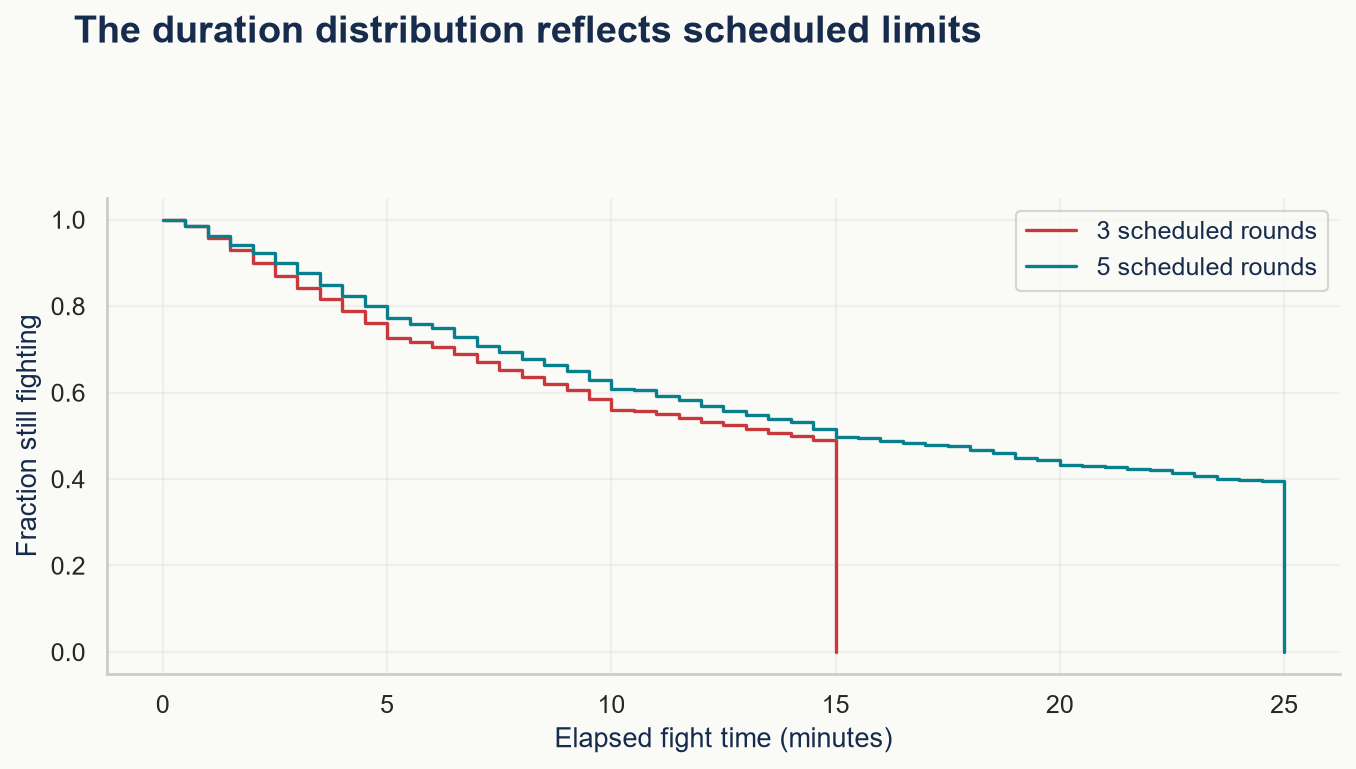

In [6]:
curve = duration_curve(fights)
style()
fig, ax = plt.subplots(figsize=(9,5))
for schedule, rows in curve.groupby('scheduled_rounds'):
    ax.step(rows.seconds/60, rows.still_fighting, where='post', label=f'{int(schedule)} scheduled rounds')
ax.set(xlabel='Elapsed fight time (minutes)', ylabel='Fraction still fighting')
ax.legend(); show(finish(fig,'The duration distribution reflects scheduled limits'))

## Research extension: Can composition, schedules and rematches explain outcomes?

The following answers are computed from the current snapshot. Tables expose denominators and missingness so the claims can be checked.

In [7]:
from src.research import run_chapter, display_answers
deep_tables, deep_answers = run_chapter('05')
display_answers(deep_answers)

### Which divisions drive the change in decision share?

**Answer.** On shared divisions, within-division changes contribute -1.12 percentage points and division-mix changes contribute +1.71. Lightweight has the most negative within-division contribution (-0.93 points).

**Interpretation.** The contributions sum exactly to the shared-cohort rate change, which differs from the all-division change. This is a symmetric accounting decomposition, not causal attribution.

### Where are judges less often unanimous when a fight reaches a decision?

**Answer.** Among divisions with at least 100 decisions, Welterweight has the largest split-or-majority share: 23.0% of 657 decisions.

**Interpretation.** The denominator is decided bouts, not every fight. Split or majority results indicate disagreement in scorecards, not proof of a wrong verdict or bias.

### Do title and non-title fights differ when both have five-round schedules?

**Answer.** Among standard five-round bouts in 2020-2025, decision shares are 47.0% for title fights and 47.6% for non-title fights.

**Interpretation.** Matching scheduled length and period removes two obvious differences. Division and athlete selection remain uncontrolled, so title status is not a treatment effect.

### How often does the first winner win the first UFC rematch?

**Answer.** The original winner repeats in 59.2% of 174 eligible first rematches with decisive results in both meetings.

**Interpretation.** Only the second observed UFC meeting is counted for each unordered pair. Rematches are selectively booked; results do not generalize to all hypothetical rematches.

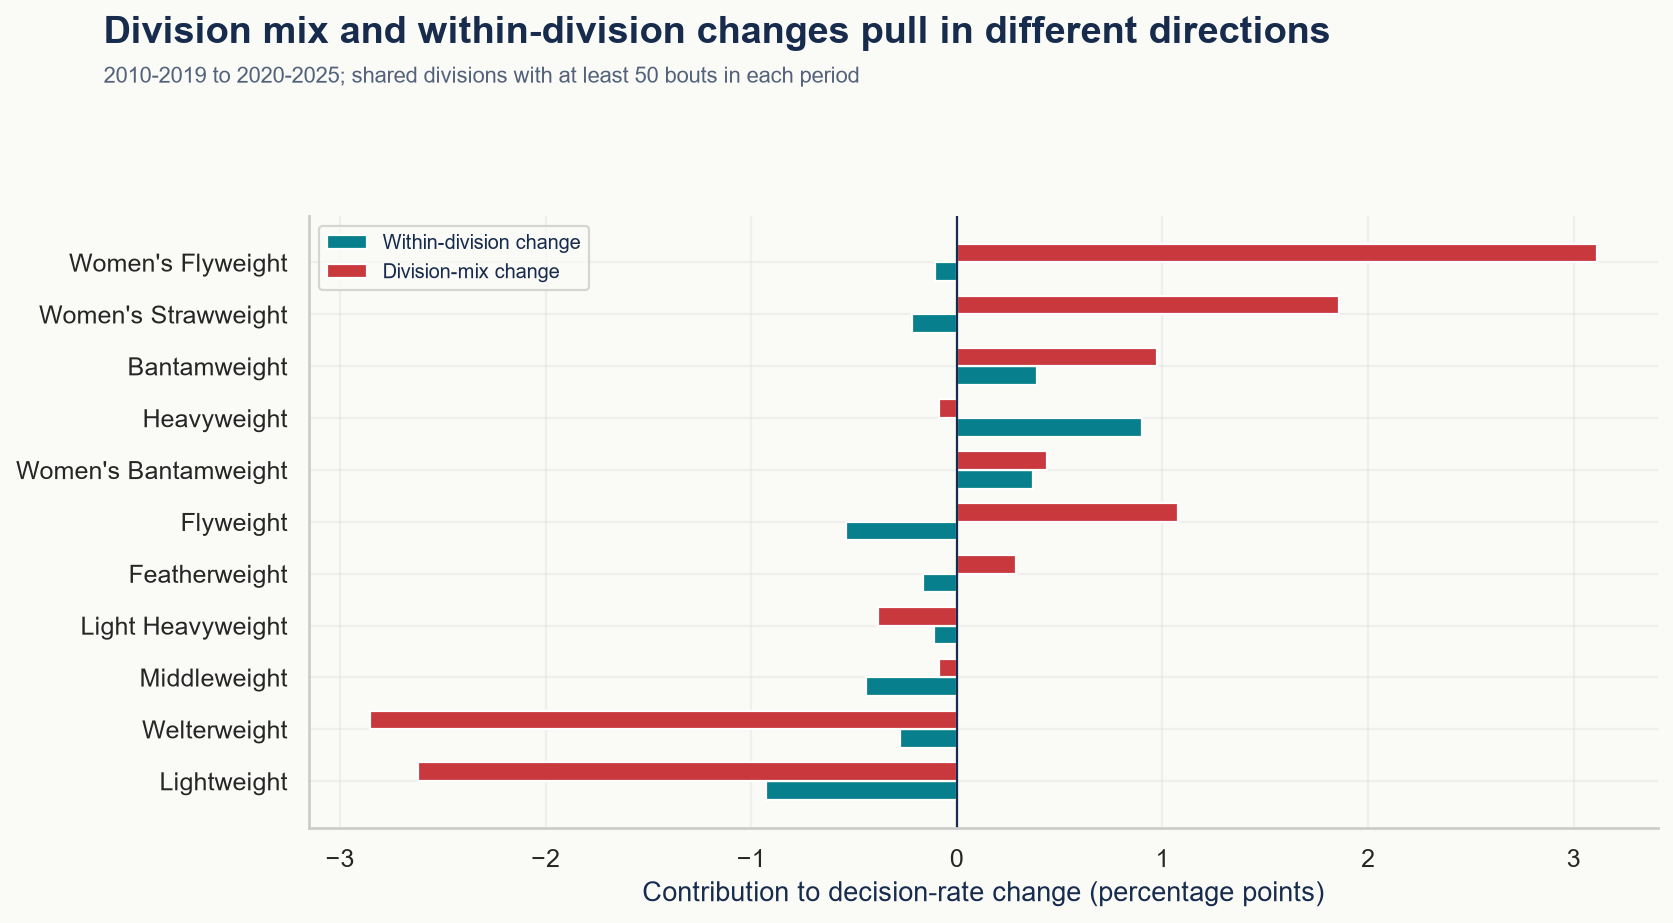

In [8]:
from src.research_visualization import research_chart
show(research_chart('05'))

In [9]:
display(deep_tables['deep_decision_decomposition'])

,weight_class,n_before,n_after,rate_before,rate_after,weight_before,weight_after,within_contribution,mix_contribution,total_contribution
0,Bantamweight,410,347,0.500000,0.536023,0.098392,0.117151,0.003882,0.009717,0.013599
1,Featherweight,478,356,0.533473,0.519663,0.114711,0.120189,-0.001622,0.002885,0.001263
2,Flyweight,198,201,0.575758,0.482587,0.047516,0.067860,-0.005375,0.010765,0.005390
3,Heavyweight,324,223,0.290123,0.408072,0.077754,0.075287,0.009025,-0.000861,0.008164
4,Light Heavyweight,348,216,0.370690,0.356481,0.083513,0.072924,-0.001111,-0.003850,-0.004962
5,Lightweight,785,394,0.501911,0.444162,0.188385,0.133018,-0.009280,-0.026190,-0.035471
6,Middleweight,518,362,0.436293,0.400552,0.124310,0.122215,-0.004406,-0.000877,-0.005282
7,Welterweight,750,359,0.494667,0.476323,0.179986,0.121202,-0.002762,-0.028539,-0.031302
8,Women's Bantamweight,126,111,0.547619,0.657658,0.030238,0.037475,0.003725,0.004361,0.008087
9,Women's Flyweight,70,196,0.642857,0.617347,0.016799,0.066172,-0.001058,0.031110,0.030052


In [10]:
display(deep_tables['deep_divided_decisions'])

,weight_class,n,successes,rate,low,high,eligible_comparison
0,Bantamweight,412,92,0.223301,0.185748,0.265966,True
1,Catch Weight,39,7,0.179487,0.089773,0.326680,False
2,Featherweight,457,93,0.203501,0.169132,0.242813,True
3,Flyweight,224,49,0.218750,0.169604,0.277380,True
4,Heavyweight,246,48,0.195122,0.150447,0.249173,True
5,Light Heavyweight,270,60,0.222222,0.176725,0.275513,True
6,Lightweight,686,154,0.224490,0.194850,0.257198,True
7,Middleweight,454,97,0.213656,0.178437,0.253681,True
8,Open Weight,8,1,0.125000,0.022417,0.470888,False
9,Other / unspecified,1,0,0.000000,0.000000,0.793451,False


In [11]:
display(deep_tables['deep_title_schedule'])

,period,title_fight,n,successes,rate,low,high
0,After,0,191,91,0.476440,0.406774,0.547034
1,After,1,117,55,0.470085,0.382043,0.560030
2,Before,0,193,48,0.248705,0.193024,0.314194
3,Before,1,169,70,0.414201,0.342648,0.489568


In [12]:
display(deep_tables['deep_rematches'])

,gap_band,n,successes,rate,low,high
0,"(0, 1]",38,26,0.684211,0.525442,0.809154
1,"(1, 3]",64,38,0.59375,0.471452,0.705431
2,"(3, 100]",72,39,0.541667,0.427399,0.651714
